In [ ]:
!pip install scikit-learn==1.2.2
!pip install xgboost==1.6.2

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/job_cleanData.csv')

In [ ]:
df.head()

,job_ID,designation,company_id,name,work_type,involvement,employees_count,total_applicants,linkedin_followers,job_details,details_id,industry,level,City,State
0,3471657636,Data Analyst,524.0,Crossover,Remote,Full-time,1001,200,5.395547e+06,About the job Crossover is the world's #1 sour...,2697,IT Services and IT Consulting,Associate,Delhi,Delhi
1,3471669068,Data Analyst,524.0,Crossover,Remote,Full-time,1001,184,5.395547e+06,About the job Crossover is the world's #1 sour...,2724,IT Services and IT Consulting,Associate,New Delhi,Delhi
2,3474349934,Data Analyst,2242.0,Uplers,Remote,Full-time,1001,200,9.821152e+05,About the job Profile: ML EngineersExperience:...,3668,IT Services and IT Consulting,Mid-Senior level,Greater Bengaluru Area,Karnataka
3,3472816027,Data Analyst,1553.0,PVAR SERVICES,On-site,Full-time,1,200,2.094000e+03,About the job Designation: Data AnalystLocatio...,3083,Not Avilable,Not Avilable,Gurugram,Haryana
4,3473311511,Data Analyst,2147.0,Timeline Freight Brokers,On-site,Full-time,1,8,9.821152e+05,About the job The ideal candidate will use the...,3359,Not Avilable,Not Avilable,Mohali district,North West


In [ ]:
df.shape

(5587, 15)

In [ ]:
df.columns

Index(['job_ID', 'designation', 'company_id', 'name', 'work_type',
       'involvement', 'employees_count', 'total_applicants',
       'linkedin_followers', 'job_details', 'details_id', 'industry', 'level',
       'City', 'State'],
      dtype='object')

In [ ]:
df.dtypes

,0
job_ID,int64
designation,object
company_id,float64
name,object
work_type,object
involvement,object
employees_count,int64
total_applicants,int64
linkedin_followers,float64
job_details,object


In [ ]:

from tabulate import tabulate
# Get numerical and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Print columns in tabular format
numeric_cols_table = pd.DataFrame(numeric_cols, columns=["Numerical Columns"])
categorical_cols_table = pd.DataFrame(categorical_cols, columns=["Categorical Columns"])

print("\nNumerical Columns:")
print(tabulate(numeric_cols_table, headers='keys', tablefmt='grid', showindex=False))

print("\nCategorical Columns:")
print(tabulate(categorical_cols_table, headers='keys', tablefmt='grid', showindex=False))


Numerical Columns:
+---------------------+
| Numerical Columns   |
+=====================+
| job_ID              |
+---------------------+
| company_id          |
+---------------------+
| employees_count     |
+---------------------+
| total_applicants    |
+---------------------+
| linkedin_followers  |
+---------------------+
| details_id          |
+---------------------+

Categorical Columns:
+-----------------------+
| Categorical Columns   |
+=======================+
| designation           |
+-----------------------+
| name                  |
+-----------------------+
| work_type             |
+-----------------------+
| involvement           |
+-----------------------+
| job_details           |
+-----------------------+
| industry              |
+-----------------------+
| level                 |
+-----------------------+
| City                  |
+-----------------------+
| State                 |
+-----------------------+


In [ ]:
# Check for missing values before imputation
missing_before = df.isnull().sum().reset_index()
missing_before.columns = ['Column', 'Missing Values']

# Print missing values before imputation in a tabular format
print("\nMissing values before imputation:")
print(tabulate(missing_before, headers='keys', tablefmt='grid', showindex=False))


Missing values before imputation:
+--------------------+------------------+
| Column             |   Missing Values |
+====================+==================+
| job_ID             |                0 |
+--------------------+------------------+
| designation        |                0 |
+--------------------+------------------+
| company_id         |                0 |
+--------------------+------------------+
| name               |                0 |
+--------------------+------------------+
| work_type          |                0 |
+--------------------+------------------+
| involvement        |                0 |
+--------------------+------------------+
| employees_count    |                0 |
+--------------------+------------------+
| total_applicants   |                0 |
+--------------------+------------------+
| linkedin_followers |                0 |
+--------------------+------------------+
| job_details        |                0 |
+--------------------+------------------+

In [ ]:
import pandas as pd
import numpy as np

# Let's define the unwanted strings exactly as they appear in your data:
replace_vals = ["Other", "Other Developer", "Other Engineering"]

# 1) Replace unwanted strings with NaN
df["designation"] = df["designation"].replace(replace_vals, np.nan)

# 2) Find the most frequent category (mode)
mode_series = df["designation"].mode(dropna=True)  # returns a Series

if not mode_series.empty:
    most_common_value = mode_series[0]  # pick the first if there's a tie
else:
    most_common_value = "Unknown"

# 3) Fill all NaNs with this most common value
df["designation"] = df["designation"].fillna(most_common_value)


In [ ]:
df.head(20)

,job_ID,designation,company_id,name,work_type,involvement,employees_count,total_applicants,linkedin_followers,job_details,details_id,industry,level,City,State
0,3471657636,Data Analyst,524.0,Crossover,Remote,Full-time,1001,200,5.395547e+06,About the job Crossover is the world's #1 sour...,2697,IT Services and IT Consulting,Associate,Delhi,Delhi
1,3471669068,Data Analyst,524.0,Crossover,Remote,Full-time,1001,184,5.395547e+06,About the job Crossover is the world's #1 sour...,2724,IT Services and IT Consulting,Associate,New Delhi,Delhi
2,3474349934,Data Analyst,2242.0,Uplers,Remote,Full-time,1001,200,9.821152e+05,About the job Profile: ML EngineersExperience:...,3668,IT Services and IT Consulting,Mid-Senior level,Greater Bengaluru Area,Karnataka
3,3472816027,Data Analyst,1553.0,PVAR SERVICES,On-site,Full-time,1,200,2.094000e+03,About the job Designation: Data AnalystLocatio...,3083,Not Avilable,Not Avilable,Gurugram,Haryana
4,3473311511,Data Analyst,2147.0,Timeline Freight Brokers,On-site,Full-time,1,8,9.821152e+05,About the job The ideal candidate will use the...,3359,Not Avilable,Not Avilable,Mohali district,North West
5,3472504479,Data Analyst,2421.0,airtel,On-site,Full-time,10001,200,9.726570e+05,About the job The ideal candidate will use the...,2901,Telecommunications,Entry level,Gurugram,Haryana
6,3471658510,Data Analyst,524.0,Crossover,Remote,Full-time,1001,200,5.395546e+06,About the job Crossover is the world's #1 sour...,2698,IT Services and IT Consulting,Associate,Bengaluru,Karnataka
7,3472808738,Shopify Developer,604.0,Digital Impressions,On-site,Full-time,51,2,1.045000e+03,About the job The ideal candidate will be resp...,3012,Not Avilable,Not Avilable,Delhi,Delhi
8,3475061559,Database Developer,1183.0,Kline & Company,Hybrid,Full-time,201,7,3.031900e+04,About the job Are you an experienced Microsoft...,3970,Not Avilable,Not Avilable,Gurugram,Haryana
9,3471883751,Shopify Developer,2234.0,Unitalks Technologies,Remote,Full-time,11,22,4.780000e+03,About the job Create an engaging and knowledge...,2829,Not Avilable,Not Avilable,Noida,Uttar Pradesh


In [ ]:
import numpy as np

# The string(s) I want to replace
replace_vals = ["Not Avilable"]

# The columns where you want to do this replacement
target_cols = ["level", "industry"]  # or any others you need

for col in target_cols:
    # 1) Replace "not available" with NaN
    df[col] = df[col].replace(replace_vals, np.nan)

    # 2) Find the mode (most frequent category) in this column
    mode_series = df[col].mode(dropna=True)  # returns a Series
    if not mode_series.empty:
        most_common_value = mode_series[0]
    else:
        most_common_value = "Unknown"


In [ ]:
df.head(20)

,job_ID,designation,company_id,name,work_type,involvement,employees_count,total_applicants,linkedin_followers,job_details,details_id,industry,level,City,State
0,3471657636,Data Analyst,524.0,Crossover,Remote,Full-time,1001,200,5.395547e+06,About the job Crossover is the world's #1 sour...,2697,IT Services and IT Consulting,Associate,Delhi,Delhi
1,3471669068,Data Analyst,524.0,Crossover,Remote,Full-time,1001,184,5.395547e+06,About the job Crossover is the world's #1 sour...,2724,IT Services and IT Consulting,Associate,New Delhi,Delhi
2,3474349934,Data Analyst,2242.0,Uplers,Remote,Full-time,1001,200,9.821152e+05,About the job Profile: ML EngineersExperience:...,3668,IT Services and IT Consulting,Mid-Senior level,Greater Bengaluru Area,Karnataka
3,3472816027,Data Analyst,1553.0,PVAR SERVICES,On-site,Full-time,1,200,2.094000e+03,About the job Designation: Data AnalystLocatio...,3083,NaN,NaN,Gurugram,Haryana
4,3473311511,Data Analyst,2147.0,Timeline Freight Brokers,On-site,Full-time,1,8,9.821152e+05,About the job The ideal candidate will use the...,3359,NaN,NaN,Mohali district,North West
5,3472504479,Data Analyst,2421.0,airtel,On-site,Full-time,10001,200,9.726570e+05,About the job The ideal candidate will use the...,2901,Telecommunications,Entry level,Gurugram,Haryana
6,3471658510,Data Analyst,524.0,Crossover,Remote,Full-time,1001,200,5.395546e+06,About the job Crossover is the world's #1 sour...,2698,IT Services and IT Consulting,Associate,Bengaluru,Karnataka
7,3472808738,Shopify Developer,604.0,Digital Impressions,On-site,Full-time,51,2,1.045000e+03,About the job The ideal candidate will be resp...,3012,NaN,NaN,Delhi,Delhi
8,3475061559,Database Developer,1183.0,Kline & Company,Hybrid,Full-time,201,7,3.031900e+04,About the job Are you an experienced Microsoft...,3970,NaN,NaN,Gurugram,Haryana
9,3471883751,Shopify Developer,2234.0,Unitalks Technologies,Remote,Full-time,11,22,4.780000e+03,About the job Create an engaging and knowledge...,2829,NaN,NaN,Noida,Uttar Pradesh


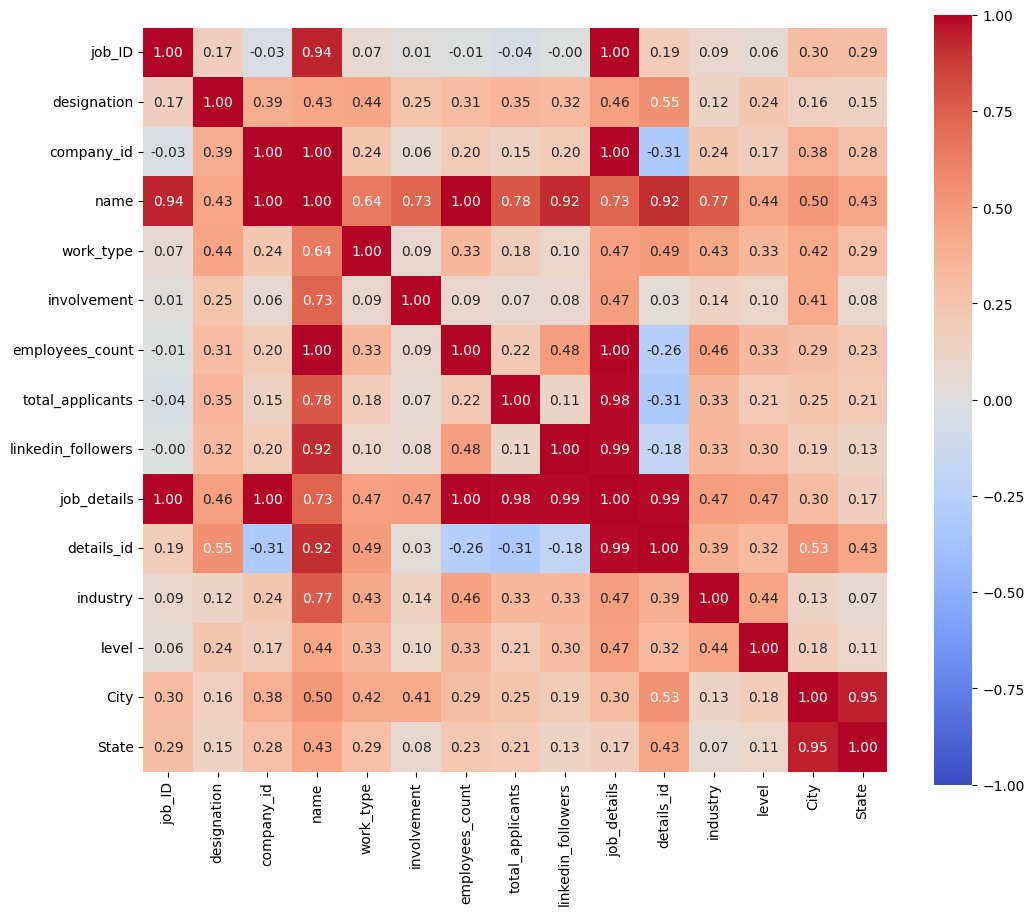

{'corr':                       job_ID  designation  company_id      name  work_type  \
 job_ID              1.000000     0.168341   -0.025342  0.944437   0.067322   
 designation         0.168341     1.000000    0.391130  0.433717   0.439891   
 company_id         -0.025342     0.391130    1.000000  1.000000   0.241961   
 name                0.944437     0.433717    1.000000  1.000000   0.641050   
 work_type           0.067322     0.439891    0.241961  0.641050   1.000000   
 involvement         0.011841     0.251374    0.063237  0.727295   0.087727   
 employees_count    -0.007662     0.305884    0.197393  0.998614   0.329733   
 total_applicants   -0.043415     0.347470    0.148318  0.780389   0.177226   
 linkedin_followers -0.002063     0.316548    0.201056  0.923584   0.103073   
 job_details         0.999925     0.463683    0.999763  0.726904   0.466655   
 details_id          0.190154     0.546333   -0.308305  0.918490   0.489200   
 industry            0.088890     0.123853  

In [ ]:
!pip install dython

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dython.nominal import associations

associations(
    df,
    nominal_columns=categorical_cols.tolist(),  # Convert Index/array -> list
    figsize=(12, 10),
    cmap='coolwarm'
)


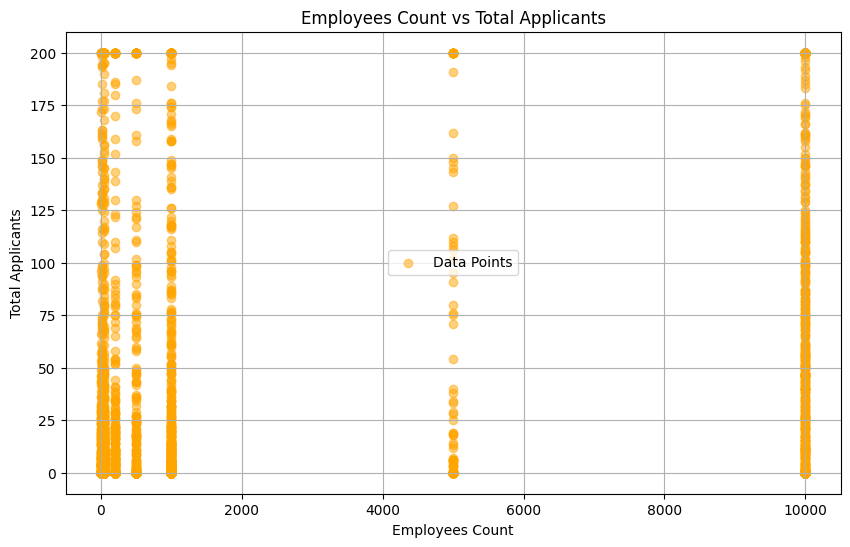

In [ ]:


# 3.3. Scatter Plot of Employees Count vs Total Applicants
plt.figure(figsize=(10, 6))
plt.scatter(df['employees_count'], df['total_applicants'], alpha=0.5, color='orange', label='Data Points')
plt.title('Employees Count vs Total Applicants')
plt.xlabel('Employees Count')
plt.ylabel('Total Applicants')
plt.legend()
plt.grid(True)
plt.show()

Total jobs with zero applicants: 3149
Total jobs with non-zero applicants: 2438


<ipython-input-13-cfa030a5c2bb>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=(df['total_applicants'] == 0), palette='coolwarm')


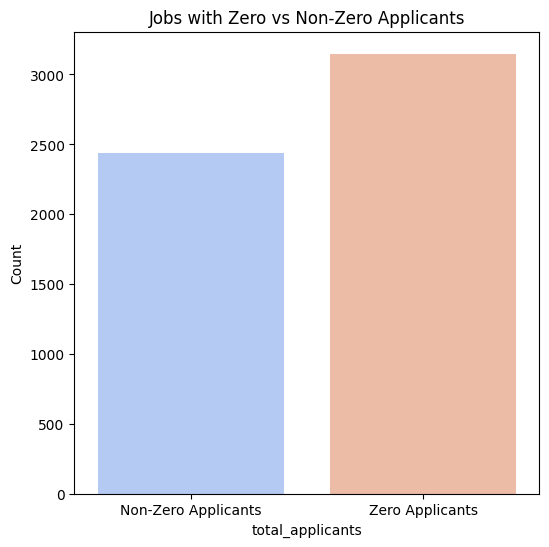

In [ ]:
# Step 1: Analyze Zeros in Total Applicants
zero_applicants = df[df['total_applicants'] == 0]
non_zero_applicants = df[df['total_applicants'] > 0]

print(f"Total jobs with zero applicants: {len(zero_applicants)}")
print(f"Total jobs with non-zero applicants: {len(non_zero_applicants)}")

# Visualize the proportion of zeros
plt.figure(figsize=(6, 6))
sns.countplot(x=(df['total_applicants'] == 0), palette='coolwarm')
plt.title('Jobs with Zero vs Non-Zero Applicants')
plt.xticks([0, 1], ['Non-Zero Applicants', 'Zero Applicants'])
plt.ylabel('Count')
plt.show()



Total jobs with zero applicants: 3149
Total jobs with non-zero applicants: 2438


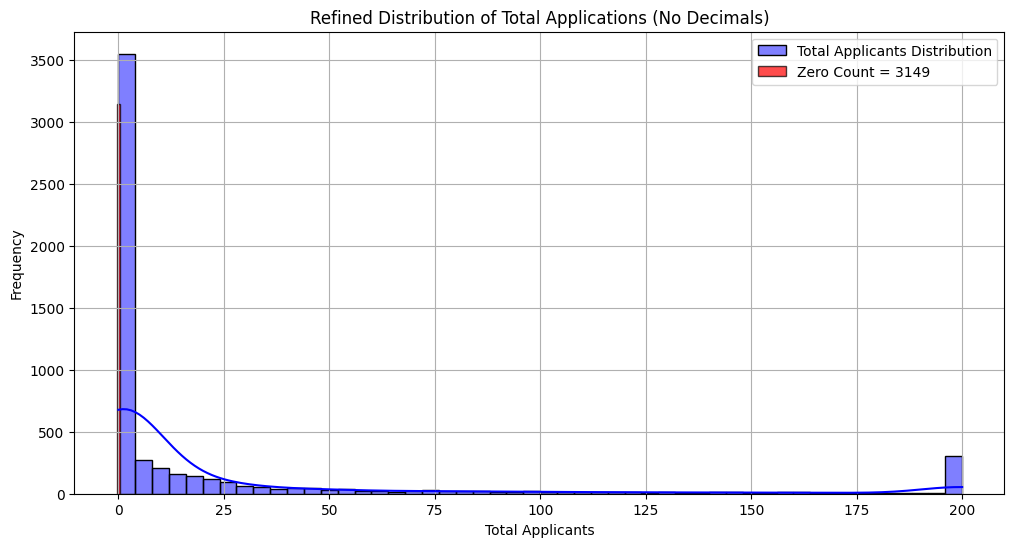

In [ ]:
# Step 1: Remove decimals by converting 'total_applicants' to integers
df['total_applicants'] = df['total_applicants'].astype(int)

# Step 2: Recalculate the count of zero applicants
zero_count = (df['total_applicants'] == 0).sum()
non_zero_count = (df['total_applicants'] != 0).sum()

print(f"Total jobs with zero applicants: {zero_count}")
print(f"Total jobs with non-zero applicants: {non_zero_count}")

# Step 3: Plot the histogram again using Seaborn for KDE
plt.figure(figsize=(12, 6))
sns.histplot(df['total_applicants'], bins=50, kde=True, color='blue', label='Total Applicants Distribution')

# Highlight zero applicants explicitly
plt.bar(0, zero_count, color='red', alpha=0.7, label=f'Zero Count = {zero_count}', edgecolor='black')

# Labels and legend
plt.title('Refined Distribution of Total Applications (No Decimals)')
plt.xlabel('Total Applicants')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

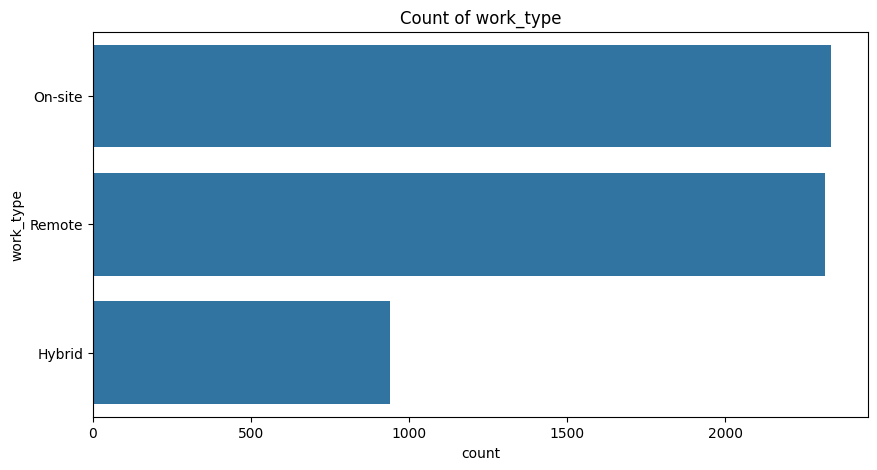

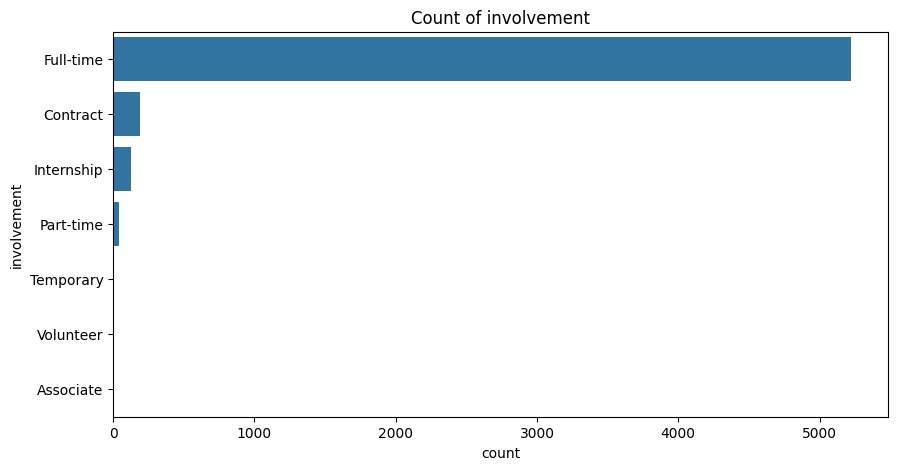

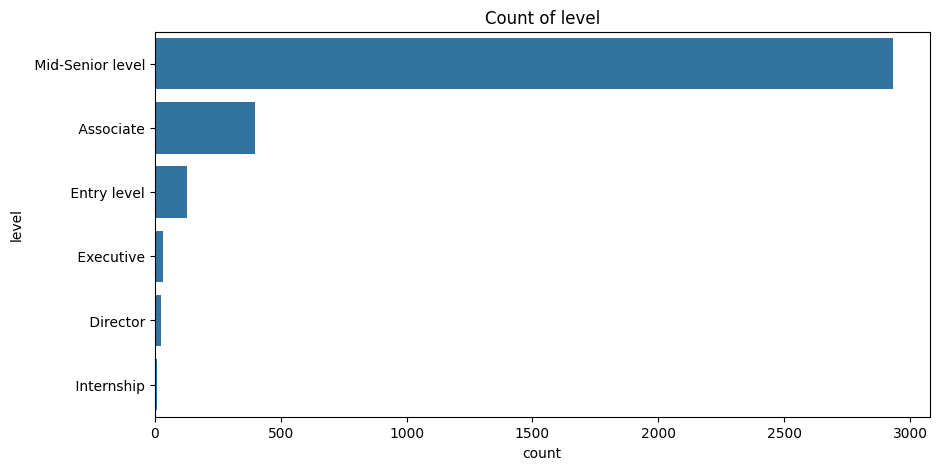

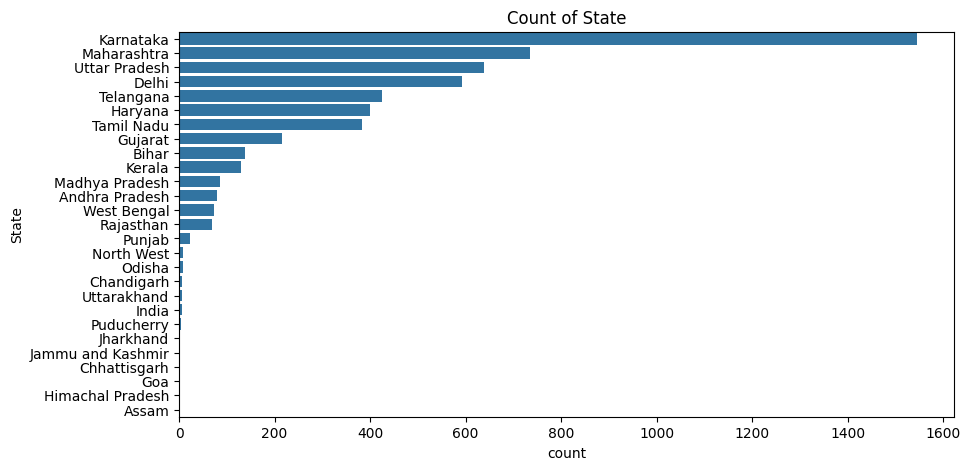

In [ ]:
# Analyze categorical columns
categorical_cols = ['work_type', 'involvement',  'level',  'State']
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.show()

In [ ]:
# Step 1: Filter out rows with zero applicants
df = df[df['total_applicants'] > 0]

In [ ]:
# Apply log transformation to the target variable
df['log_total_applicants'] = np.log1p(df['total_applicants'])

# Define target variable and features
y = df['log_total_applicants']  # Transformed target variable
X = df.drop(columns=['total_applicants', 'log_total_applicants','name','job_details'])

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

# Separate numeric and categorical columns
numeric_columns = X.select_dtypes(include=[np.number]).columns
categorical_columns = X.select_dtypes(exclude=[np.number]).columns

# One-Hot Encoding for Categorical Columns
X_train_categorical_encoded = pd.get_dummies(X_train[categorical_columns], drop_first=True)
X_test_categorical_encoded = pd.get_dummies(X_test[categorical_columns], drop_first=True)

# Align the train and test datasets to ensure they have the same columns after encoding
X_train_categorical_encoded, X_test_categorical_encoded = X_train_categorical_encoded.align(
    X_test_categorical_encoded, join='left', axis=1, fill_value=0
)

# Combine numeric and encoded categorical data
X_train_combined = pd.concat([X_train[numeric_columns].reset_index(drop=True), X_train_categorical_encoded.reset_index(drop=True)], axis=1)
X_test_combined = pd.concat([X_test[numeric_columns].reset_index(drop=True), X_test_categorical_encoded.reset_index(drop=True)], axis=1)

# Scale the combined dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

In [ ]:
# Random Forest Model
start_time_rf = time.time()
rf_params = {
    'n_estimators': [100, 200,300,400,500,600,700,800],
    'max_depth': [10, 15,20,25,30,35,40,45],
    'min_samples_split': [2, 5,8,11,14,17,21,24],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, scoring='r2', cv=5, verbose=1, n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
training_time_rf = time.time() - start_time_rf
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_scaled)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

Fitting 5 folds for each of 1024 candidates, totalling 5120 fits


In [ ]:
# Gradient Boosting Model
start_time_gb = time.time()
gb_params = {
    'n_estimators': [100,200,300,400,500,600,700],
    'learning_rate': [0.1, 0.2,0.3,0.4,0.5,0.6,0.7],
    'max_depth': [3, 5, 7,9,11,14,27],
    'min_samples_leaf': [1, 3, 5,7,9,11,13]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, scoring='r2', cv=5, verbose=1, n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)
training_time_gb = time.time() - start_time_gb
gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test_scaled)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)

Fitting 5 folds for each of 2401 candidates, totalling 12005 fits


In [ ]:
# XGBoost Model
start_time_xgb = time.time()
xgb_params = {
    'n_estimators': [100, 150, 200,300],
    'learning_rate': [0.05, 0.1, 0.2,0.3],
    'max_depth': [3, 5, 7,9],
    'subsample': [0.8, 1.0,1.2],
    'colsample_bytree': [0.8, 1.0,1.2]
}
# This grid has 4 * 3 * 3 * 2 * 2 = 64 combinations
xgb_grid = GridSearchCV(XGBRegressor(random_state=42, use_label_encoder=False, verbosity=0), xgb_params, scoring='r2', cv=5, verbose=1, n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
training_time_xgb = time.time() - start_time_xgb
xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test_scaled)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
1600 fits failed out of a total of 2880.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
640 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 575, in inner_f
    return f(**kwargs)
  File "/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py", line 961, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/xgboost/core.py", line 575, in inner_f
 

In [ ]:
# Support Vector Regression (SVR) Model
start_time_svr = time.time()
svr_params = {
    'C': [ 1.0, 2.0,3.0,4.0,5.0],
    'epsilon': [0.1, 0.2,0.3,0.4,0.5],
    'kernel': ['rbf']
}
svr_grid = GridSearchCV(SVR(), svr_params, scoring='r2', cv=5, verbose=1, n_jobs=-1)
svr_grid.fit(X_train_scaled, y_train)
training_time_svr = time.time() - start_time_svr
svr_best = svr_grid.best_estimator_
svr_pred = svr_best.predict(X_test_scaled)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2 = r2_score(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [ ]:
# Compile results
results_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost", "SVM"],
    "Best Parameters": [rf_grid.best_params_, gb_grid.best_params_, xgb_grid.best_params_, svr_grid.best_params_],
    "RMSE": [rf_rmse, gb_rmse, xgb_rmse, svr_rmse],
    "R²": [rf_r2, gb_r2, xgb_r2, svr_r2],
    "MAE": [rf_mae, gb_mae, xgb_mae, svr_mae],
    "Training Time (s)": [training_time_rf, training_time_gb, training_time_xgb, training_time_svr]
})

In [ ]:
# Display results
print("\nOptimized Model Performance Metrics (Log-Transformed Target):")
print(results_df)


Optimized Model Performance Metrics (Log-Transformed Target):
               Model                                    Best Parameters  \
0      Random Forest  {'max_depth': 45, 'max_features': 'sqrt', 'min...   
1  Gradient Boosting  {'learning_rate': 0.2, 'max_depth': 3, 'min_sa...   
2            XGBoost  {'colsample_bytree': 0.8, 'learning_rate': 0.1...   
3                SVM        {'C': 5.0, 'epsilon': 0.3, 'kernel': 'rbf'}   

       RMSE        R²       MAE  Training Time (s)  
0  1.043134  0.449716  0.843274        6862.476592  
1  1.009029  0.485111  0.794652        3444.363745  
2  1.020506  0.473332  0.798451        6385.496114  
3  1.152307  0.328505  0.917022          59.075802  


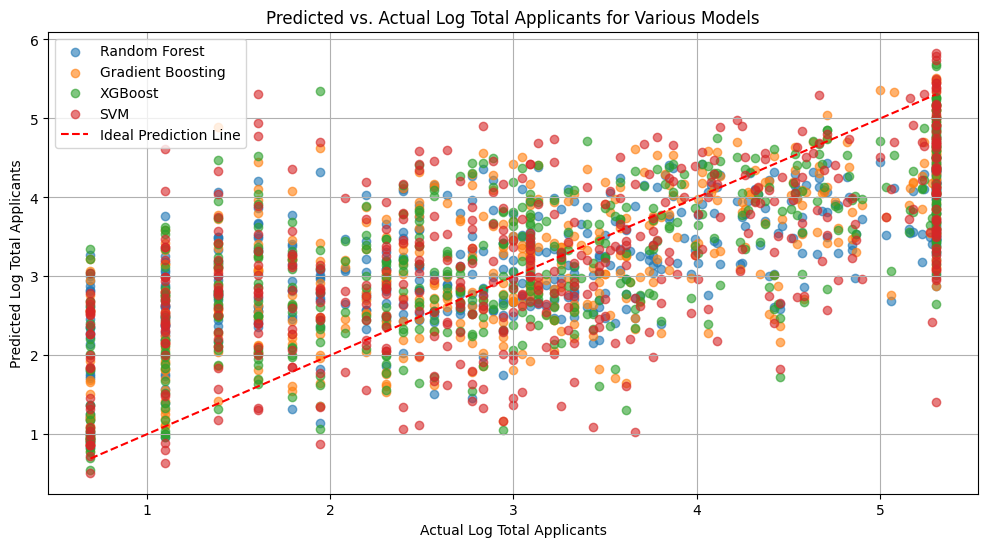

In [ ]:
# Visualization: Predicted vs Actual
plt.figure(figsize=(12, 6))
plt.scatter(y_test, rf_pred, alpha=0.6, label="Random Forest")
plt.scatter(y_test, gb_pred, alpha=0.6, label="Gradient Boosting")
plt.scatter(y_test, xgb_pred, alpha=0.6, label="XGBoost")
plt.scatter(y_test, svr_pred, alpha=0.6, label="SVM")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Prediction Line')
plt.xlabel('Actual Log Total Applicants')
plt.ylabel('Predicted Log Total Applicants')
plt.title('Predicted vs. Actual Log Total Applicants for Various Models')
plt.legend()
plt.grid(True)
plt.show()